In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
DATA_DIR = Path("/Users/sean/code/study-hard/power-systems-ops/data/" )
STUDY_DIR = DATA_DIR / "Multi-Stage_Aging_Study"

In [4]:
STUDY_DIR

PosixPath('/Users/sean/code/study-hard/power-systems-ops/data/Multi-Stage_Aging_Study')

In [5]:
from power_systems_ops.battery.data_import import import_datafile

In [6]:
meta_df = pd.read_csv(STUDY_DIR / "experiments_meta.csv")

In [7]:
meta_df.describe()

,tp,cell,amb_temp_tp,soc_max_tp,dod_tp,c_ch_tp,c_dch_tp,stage,m_0,R_1khz_0,U_0
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,9.559140,2.709677,32.505376,0.631935,0.168280,0.321720,0.566452,1.494624,68.637774,12.914849,3.575188
std,6.529615,1.516675,12.306888,0.256742,0.223862,0.373785,0.694446,0.500870,0.289905,0.568617,0.001363
min,1.000000,1.000000,10.000000,0.050000,0.000000,0.000000,0.000000,1.000000,67.986000,11.840000,3.571480
25%,4.000000,1.000000,23.000000,0.500000,0.000000,0.000000,0.000000,1.000000,68.335500,12.464000,3.574000
50%,8.000000,2.000000,35.000000,0.740000,0.050000,0.200000,0.260000,1.000000,68.721000,12.923000,3.575000
75%,13.000000,3.000000,45.000000,0.800000,0.300000,0.700000,1.000000,2.000000,68.880000,13.335000,3.576000
max,25.000000,6.000000,45.000000,1.000000,0.600000,1.000000,2.000000,2.000000,69.070000,14.420000,3.579900


In [8]:

# Find the file

def find_files(stage, aging_type, tp, cell):
    path = STUDY_DIR / f"Stage_{stage}"
    files = list(path.rglob(f"*_{aging_type}{tp:02d}_{cell:02d}_*.csv"))
    print(f"Matching files: {len(files)}")
    print(files[0])
    files.sort()
    return files

In [29]:
import power_systems_ops.battery.feature_extraction as ext

# Calendar Aging

In [30]:
# Select the dataset to be imported
stage = 1   # Doesn't matter to me
aging_type = 'k'  # Calendar (k) and Cycling (z)

tp = 8  # Experiment Number
cell = 1  # Cell Number

files = find_files(stage, aging_type, tp, cell)
t, cap, _ = capacity_vs_time(files, 23)

Matching files: 12
/Users/sean/code/study-hard/power-systems-ops/data/Multi-Stage_Aging_Study/Stage_1/47628304_TP_k08_01/TP_k08_01/TP_k08_01_02_CU.csv
Found 8 at same temp


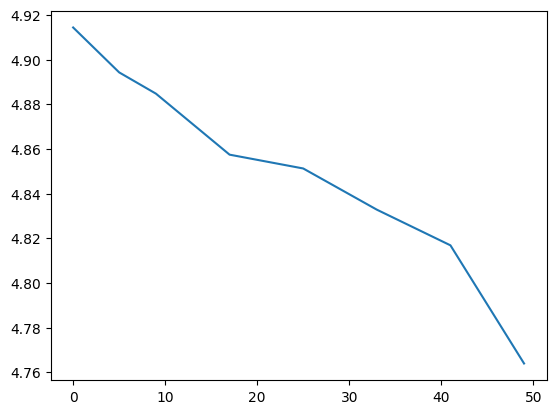

In [31]:
plt.plot(t, cap)

In [32]:
def extract_calendar(df):
    c = ext.capacity(ext.df_capacity(df))['Q_mean']
    T = df['amb_temp'].mean()
    return (c, T)

In [33]:
T_calendar = [10, 23, 35, 45]

def filt_common_temp(cap, atol=5):
    filt = [np.isclose(cap[:, 1], T, atol=atol) for T in T_calendar]
    i = np.argmax([np.sum(f) for f in filt])
    return cap[filt[i]]

In [34]:
from typing import Optional
import re

def extract_two_digits(s: str) -> Optional[int]:
    """
    If `s` ends with 'T' followed by any two digits, return that number as an int.
    Otherwise return None.
    """
    m = re.search(r'T(\d{2})$', s)
    return int(m.group(1)) if m else None

In [35]:
def default_temperature(files, T_amb):
    # Some of the ambient temperatures measurements are missing, so we'll replace them with 
    # default values: the start-up and end checkups have their filenames ending in T10, T23, T45
    # For all the other checkups, we'll just assume it's the ambient temperature. 
    T_file = [extract_two_digits(f.stem) for f in files]
    return np.array(
        [T_f if T_f is not None else T_amb
         for T_f in T_file]
    )

In [36]:
class KnownIssue(Exception):
    pass
    

In [37]:
def capacity_vs_time(files, T_amb):
    cap = np.array([extract_calendar(import_datafile(f)) for f in files])
    
    T_default = default_temperature(files, T_amb)
    T_ext = cap[:, 1]
    mask = np.isnan(T_ext) 
    T_ext[mask] = T_default[mask]
    
    f_cap = filt_common_temp(cap)
    print(f"Found {len(f_cap)} at same temp")
    if len(f_cap) < 3:
        raise KnownIssue()
    # The logic here is a bit fragile and dependent on which values are filtered...
    # Should really read the meta file for the dates!
    t = np.cumsum([0, 5, 4] + [8] * (len(f_cap) - 3))
    # (t, capacity, T_amb)
    return (t, f_cap[:, 0], f_cap[:, 1])
    
def calendar_degradation(files, T_amb):
    t, cap, _ = capacity_vs_time(files, T_amb)
    
    A = np.c_[np.ones_like(t), t]
    b = cap
    x, error, _, _ = np.linalg.lstsq(A, b)
    c0, beta = x
    print(f"Found (c0, beta, error): ({c0}, {beta}, {error})")
    return -beta

In [38]:
results = []
for i, row in meta_df.iterrows():
    print(f"experiment {i}")
    if row.type != 'k':
        print("Skipping cycle aging")
        continue
    experiment_files = find_files(row.stage, row.type, row.tp, row.cell)
    # results.append((row, calendar_degradation(experiment_files, row.amb_temp_tp)))
    try:
        results.append((row, calendar_degradation(experiment_files, row.amb_temp_tp)))
    except KnownIssue:
        print(f"Warning: failed on {row.serial}")

experiment 0
Matching files: 13
/Users/sean/code/study-hard/power-systems-ops/data/Multi-Stage_Aging_Study/Stage_1/47627050_TP_k01_01/TP_k01_01/TP_k01_01_01_ET_T45.csv
Found 9 at same temp
Found (c0, beta, error): (4.906826601345245, -0.0005786197906347672, [0.01553916])
experiment 1
Matching files: 13
/Users/sean/code/study-hard/power-systems-ops/data/Multi-Stage_Aging_Study/Stage_1/47627056_TP_k01_02/TP_k01_02/TP_k01_02_03_exCU.csv
Found 9 at same temp
Found (c0, beta, error): (4.860455145931278, -0.0005864044585428928, [0.01620036])
experiment 2
Matching files: 13
/Users/sean/code/study-hard/power-systems-ops/data/Multi-Stage_Aging_Study/Stage_1/47627068_TP_k01_03/TP_k01_03/TP_k01_03_09_AT_T45.csv
Found 9 at same temp
Found (c0, beta, error): (4.898396502745838, -0.00024134862660297196, [0.01636237])
experiment 3
Matching files: 13
/Users/sean/code/study-hard/power-systems-ops/data/Multi-Stage_Aging_Study/Stage_1/47627095_TP_k02_01/TP_k02_01/TP_k02_01_06_CU.csv
Found 9 at same temp


In [80]:
beta = np.asarray([beta for _, beta in results])
T_amb = np.asarray([row.amb_temp_tp for row, _ in results])
SoC = np.asarray([row.soc_max_tp for row, _ in results])


In [81]:
def fit_each_temp(SoC, beta, T_amb):
    SoC_range = np.array([min(SoC), max(SoC)])
    beta_fit = {}
    
    np.unique(T_amb)
    for T in np.unique(T_amb):
        n_match = np.sum(T_amb == T)
        A = np.c_[
            np.ones(n_match), SoC[T_amb == T]
        ]
        b = beta[T_amb == T]
        # beta_q = x[0] + x[1] * q
        x = np.linalg.lstsq(A, b)[0]
        beta_fit[T] = x[0] + x[1] * SoC_range

    return SoC_range, beta_fit

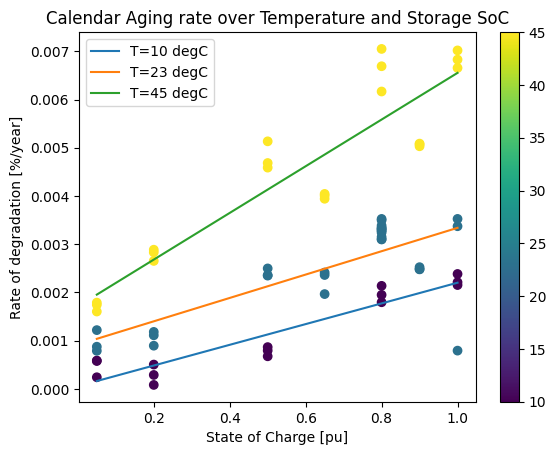

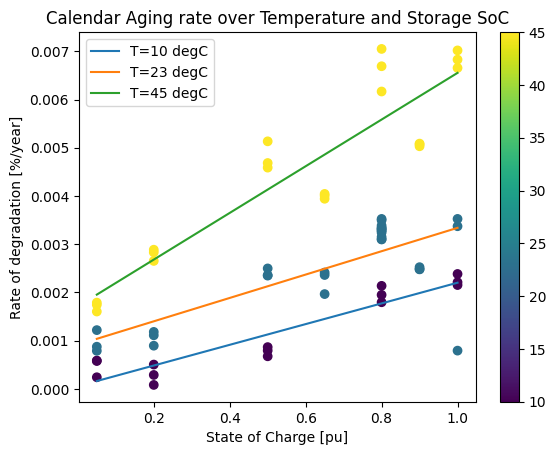

In [89]:
def plot_soc_dependence(SoC, beta, T_amb, fit_result):
    SoC_range, beta_fit = fit_result

    fig = plt.figure()
    plt.scatter(x=SoC, y=beta, c=T_amb, marker="o")
    for T, beta_f in beta_fit.items():
        plt.plot(SoC_range, beta_f, label=f"T={T} degC")
    plt.colorbar()
    plt.title("Calendar Aging rate over Temperature and Storage SoC")
    plt.legend()
    plt.xlabel("State of Charge [pu]")
    plt.ylabel("Rate of degradation [%/year]")
    return fig

beta_fit = fit_each_temp(SoC, beta, T_amb)
plot_soc_dependence(SoC, beta, T_amb, beta_fit)
                 

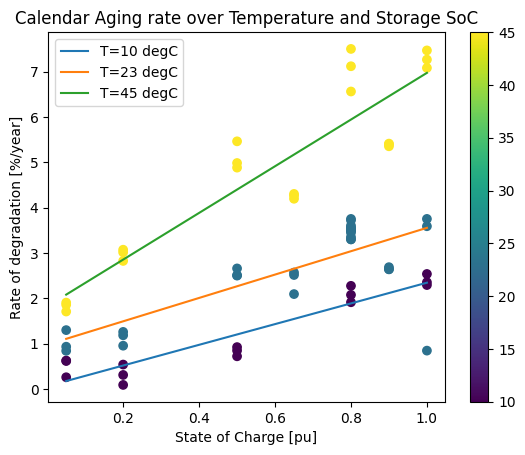

In [90]:
# (Ah) / Ah_total * 100 / week => percentage / week * 365 days/year * 1day/7weeks
Ah_total = 4.9
beta_pu = beta / Ah_total * 100 * 365 / 7
beta_pu_fit = fit_each_temp(SoC, beta_pu, T_amb)
fig = plot_soc_dependence(SoC, beta_pu, T_amb, beta_pu_fit)

In [91]:
DATA_DIR

PosixPath('/Users/sean/code/study-hard/power-systems-ops/data')

In [92]:
fig.savefig(DATA_DIR / "battery_deg" / "deg_vs_soc.png")

(array([ 7.,  9.,  8., 12., 15.,  3.,  2.,  4.,  1.,  5.]),
 array([8.21650231e-05, 7.78965335e-04, 1.47576565e-03, 2.17256596e-03,
        2.86936627e-03, 3.56616658e-03, 4.26296689e-03, 4.95976720e-03,
        5.65656752e-03, 6.35336783e-03, 7.05016814e-03]),
 <BarContainer object of 10 artists>)

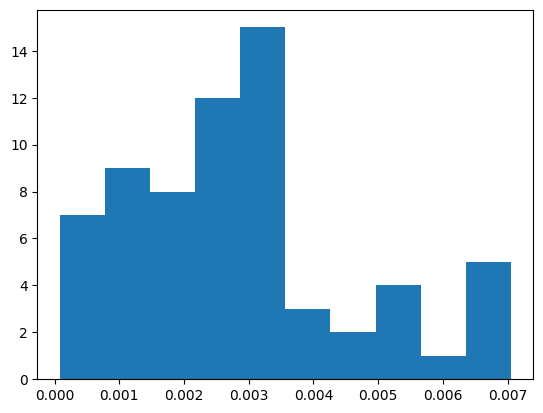

In [44]:
plt.hist(beta)

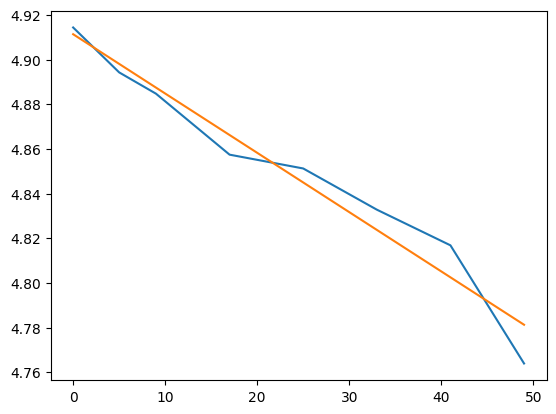

In [113]:
# Linear estimate
t_hat = np.linspace(min(t), max(t))
c_hat = c0 + t_hat * beta
plt.plot(calendar_cap[:, 2], calendar_cap[:, 0])
plt.plot(t_hat, c_hat)

In [85]:
t

array([0, 5, 4, 8, 8, 8, 8, 8, 8, 8, 8])

In [86]:
len(f_cap)

8

In [71]:
len(t)

3

In [46]:
np.mean(cap[:, 1])

np.float64(26.53690039948746)

In [44]:
print(cap[:, 1])

[ 9.99268283 22.99405867 45.03137021 22.98548617 22.99717379 23.00592945
 22.99203482 23.00379667 22.99595199  9.99119203 25.48132213 66.97180603]


In [43]:
print(cap.shape)

(12, 2)


In [35]:
df = import_datafile(file[0])
df.head()

,run_time,c_vol,c_cur,c_surf_temp,amb_temp,step_type
0,0.0000,3.515543,0.0,35.57893,0.000000,0
1,0.0021,3.515543,0.0,35.57893,0.000000,0
2,10.0000,3.516306,0.0,35.57565,35.004673,0
3,20.0000,3.516497,0.0,35.57565,34.983028,0
4,30.0000,3.515543,0.0,35.57565,35.004917,0


In [46]:
np.nanmean([np.nan, np.nan])

/var/folders/t2/6c2q8fsd3dq21_7dzq7c6n6w0000gn/T/ipykernel_34381/2006840581.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean([np.nan, np.nan])


np.float64(nan)

In [21]:
T

np.float64(23.015748436976764)

In [18]:
file[0].name

'TP_z08_01_11_CU.csv'

In [17]:
c

np.float64(4.780677173083463)

In [15]:
c

{'Q_mean': np.float64(4.780677173083463),
 'Q_ch': np.float64(4.774801425046293),
 'Q_dch': np.float64(4.7865529211206335),
 'q_ch': array([    0.        ,    24.49545658,    48.99492707,    73.49507939,
           97.99596672,   122.49595957,   146.99521742,   171.4948917 ,
          195.99567271,   220.49571872,   244.99571157,   269.49491665,
          293.99469726,   318.49479642,   342.99515293,   367.49514578,
          391.99435086,   416.49445003,   440.99439012,   465.49476704,
          489.99516437,   514.49485945,   538.99448097,   563.49420841,
          587.99446706,   612.49461939,   636.99482488,   661.49529577,
          685.99569309,   710.49538818,   734.99516878,   759.49500255,
          783.99526119,   808.4953072 ,   832.99570453,   857.49539961,
          881.99539286,   906.49549202,   930.9958566 ,   955.49595576,
          979.99605493,  1004.49645226,  1028.99598786,  1053.49643835,
         1077.99639884,  1102.4962326 ,  1126.99622545,  1151.49611237,
    